In [97]:
pip install datasets


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [98]:
from datasets import load_dataset

dataset_name = "ttchopper/openfundex"
dataset = load_dataset(dataset_name)

## 1. Load the bankruptcy dataset

I begin by loading the `ttchopper/openfundex` dataset from Hugging Face. The dataset contains company-level financial information together with a target indicating whether a company becomes bankrupt within one year.

The existing train, validation, and test splits are preserved. The training split is used to learn model parameters and preprocessing rules, the validation split is used to make modeling decisions, and the test split is kept for the final out-of-sample assessment. This separation is important because a model should not influence the data used to judge its performance.

In [99]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['cik', 'ticker', 'company_name', 'adsh', 'sic', 'fiscal_year', 'fiscal_quarter', 'filing_date', 'period_end_date', 'total_assets', 'current_assets', 'cash_and_equivalents', 'short_term_investments', 'accounts_receivable', 'inventory', 'property_plant_equipment', 'goodwill', 'intangible_assets', 'total_liabilities', 'current_liabilities', 'accounts_payable', 'long_term_debt', 'total_debt', 'stockholders_equity', 'retained_earnings', 'revenue', 'cost_of_revenue', 'gross_profit', 'operating_income', 'net_income', 'eps_basic', 'eps_diluted', 'interest_expense', 'income_tax_expense', 'depreciation_amortization', 'research_development', 'sga_expense', 'operating_cash_flow', 'capex', 'dividends_paid', 'shares_outstanding', 'free_cash_flow', 'book_value_per_share', 'gross_margin', 'operating_margin', 'net_margin', 'roe', 'roa', 'debt_to_equity', 'current_ratio', 'f_roa', 'f_cfo', 'f_delta_roa', 'f_accrual', 'f_delta_lever', 'f_delta_liquid'

In [100]:
print(dataset['train'][0])

{'cik': 929887, 'ticker': None, 'company_name': 'APOLLO GROUP INC', 'adsh': '0000950123-10-000976', 'sic': 8200, 'fiscal_year': 2010, 'fiscal_quarter': 'Q1', 'filing_date': datetime.date(2010, 1, 7), 'period_end_date': datetime.date(2009, 11, 30), 'total_assets': 3265034000.0, 'current_assets': 1857002000.0, 'cash_and_equivalents': 905262000.0, 'short_term_investments': None, 'accounts_receivable': 340973000.0, 'inventory': None, 'property_plant_equipment': 577453000.0, 'goodwill': 527177000.0, 'intangible_assets': 198020000.0, 'total_liabilities': 1749460000.0, 'current_liabilities': 1461397000.0, 'accounts_payable': 74809000.0, 'long_term_debt': None, 'total_debt': None, 'stockholders_equity': 1450281000.0, 'retained_earnings': 3435185000.0, 'revenue': 1270301000.0, 'cost_of_revenue': None, 'gross_profit': None, 'operating_income': 392895000.0, 'net_income': 240142000.0, 'eps_basic': 1.55, 'eps_diluted': 1.54, 'interest_expense': 2911000.0, 'income_tax_expense': 149918000.0, 'depreci

In [101]:
# Convert the train split to a pandas DataFrame for easier wrangling
df = dataset['train'].to_pandas()

print("DataFrame created successfully!")
display(df.head())

DataFrame created successfully!


,cik,ticker,company_name,adsh,sic,fiscal_year,fiscal_quarter,filing_date,period_end_date,total_assets,...,target_roe_fwd_1y_rank,target_margin_expansion_1y_rank,target_bvps_growth_2y_rank,target_equity_growth_2y_rank,target_earnings_growth_2y_rank,target_revenue_growth_2y_rank,target_ocf_growth_2y_rank,target_fcf_growth_2y_rank,label_timestamp,split
0,929887,NaN,APOLLO GROUP INC,0000950123-10-000976,8200.0,2010.0,Q1,2010-01-07,2009-11-30,3.265034e+09,...,0.049412,0.007067,0.037500,0.074341,0.092857,0.046036,NaN,NaN,2026-05-15 00:50:06.954478,train
1,885639,KSS,KOHLS CORPORATION,0001193125-10-061795,5311.0,2009.0,FY,2010-03-19,2010-01-31,1.316000e+10,...,NaN,NaN,NaN,0.110312,0.395238,0.342711,0.312500,0.375000,2026-05-15 00:50:06.954478,train
2,1133421,NOC,NORTHROP GRUMMAN CORP /DE/,0000950123-10-010126,3812.0,2009.0,FY,2010-02-09,2009-12-31,3.025200e+10,...,0.656471,0.565371,0.259375,0.098321,0.445238,0.056266,0.350000,0.579545,2026-05-15 00:50:06.954478,train
3,1056239,NaN,L 3 COMMUNICATIONS HOLDINGS INC,0000950123-10-017377,3663.0,2009.0,FY,2010-02-26,2009-12-31,1.481300e+10,...,0.167059,NaN,0.490625,0.285372,0.307143,0.143223,0.415625,0.564394,2026-05-15 00:50:06.954478,train
4,1116132,TPR,COACH INC,0001144204-10-005154,3100.0,2010.0,Q2,2010-02-03,2009-12-31,2.869130e+09,...,0.722353,0.371025,0.421875,0.256595,0.559524,0.744246,NaN,NaN,2026-05-15 00:50:06.954478,train


In [102]:
# Inspect data types of all columns
print("Data types of columns:")
display(df.info())

Data types of columns:
<class 'pandas.DataFrame'>
RangeIndex: 216023 entries, 0 to 216022
Columns: 120 entries, cik to split
dtypes: bool(6), datetime64[us](3), float64(88), int64(1), int8(4), object(10), str(8)
memory usage: 195.6+ MB


None

In [103]:
import pandas as pd

# Check for missing values
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_info = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
})

# Filter to show only columns with missing values and sort them
missing_info = missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)

print("Columns with missing values:")
display(missing_info)

Columns with missing values:


,Missing Count,Missing Percentage
bankruptcy_chapter,202438,93.711318
bankruptcy_date,200929,93.012781
f_score,199780,92.480893
short_term_investments,184563,85.436736
dividends_paid,182476,84.470635
...,...,...
graham_defensive_score,456,0.211089
sic,34,0.015739
fiscal_quarter,8,0.003703
fiscal_year,8,0.003703


In [104]:
import numpy as np
from scipy.stats.mstats import winsorize
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Loading & Splits ---
# The 'train' split is already loaded into `df`.
# Now, load 'validation' and 'test' splits.
df_val = dataset['validation'].to_pandas()
df_test = dataset['test'].to_pandas()

print("Loaded train, validation, and test datasets.")
print(f"Train shape: {df.shape}")
print(f"Validation shape: {df_val.shape}")
print(f"Test shape: {df_test.shape}")

Loaded train, validation, and test datasets.
Train shape: (216023, 120)
Validation shape: (43875, 120)
Test shape: (46039, 120)


In [105]:
# --- 2. Filtering: Exclude financial firms ---
# Assuming 'is_financial' == True means financial firms, and we need to exclude them (keep non-financial).
# If `is_financial == 0` means financial, then we need to filter `df = df[df['is_financial'] != 0]`.
# Based on the sample output, `is_financial` is a boolean (False for APOLLO GROUP INC).
# So, to exclude financial firms, we keep rows where `is_financial == False`.

df = df[df['is_financial'] == False].copy()
df_val = df_val[df_val['is_financial'] == False].copy()
df_test = df_test[df_test['is_financial'] == False].copy()

print("Filtered out financial firms from all splits.")
print(f"Train shape after filtering: {df.shape}")
print(f"Validation shape after filtering: {df_val.shape}")
print(f"Test shape after filtering: {df_test.shape}")

Filtered out financial firms from all splits.
Train shape after filtering: (162002, 120)
Validation shape after filtering: (32060, 120)
Test shape after filtering: (33853, 120)


## 2. Build a leakage-aware modeling table

I remove financial firms before modeling because banks, insurers, and other financial businesses have balance sheets and default mechanisms that are not directly comparable with ordinary operating companies. The filter is applied consistently to every split so that the model sees the same population definition during training and evaluation.

The experiment predicts `target_bankrupt_1y`. The feature table contains financial ratios and accounting indicators such as leverage, liquidity, profitability, cash conversion, and book value. The target is kept separate from the predictors so no outcome information is accidentally passed into a model as an input.

In [106]:
# --- 3. Feature and Target Separation ---

TARGET_VARIABLE = 'target_bankrupt_1y'

# Define the base feature set
BASE_FEATURES = [
    'debt_to_equity', 'current_ratio', 'roe', 'roa', 'gross_margin',
    'operating_margin', 'net_margin', 'f_score', 'z_prime_score',
    'cash_conversion_ratio', 'accrual_ratio', 'free_cash_flow_margin',
    'book_value_per_share', 'tangible_book_value_per_share', 'net_working_capital_per_share'
]

# Separate target variable from features for all splits
y_train = df[TARGET_VARIABLE]
y_val = df_val[TARGET_VARIABLE]
y_test = df_test[TARGET_VARIABLE]

# Create initial feature DataFrames
X_train = df[BASE_FEATURES].copy()
X_val = df_val[BASE_FEATURES].copy()
X_test = df_test[BASE_FEATURES].copy()

# Explicit Exclusions from features (already handled by selecting BASE_FEATURES,
# but double-check and remove any other irrelevant columns if present in BASE_FEATURES)
# The BASE_FEATURES list already excludes 'target_*', 'fiscal_*', 'filing_date', 'is_bankrupt'.

print("Separated target variable and initial feature sets.")

Separated target variable and initial feature sets.


In [107]:
# --- 4. Feature Selection based on Missingness (Training Set Only) ---

# Calculate missing percentage for each BASE_FEATURE in the training set
missing_percentage_train = (X_train.isnull().sum() / len(X_train)) * 100

# Identify features with more than 60% missingness
features_to_drop = missing_percentage_train[missing_percentage_train > 60].index.tolist()

# Determine final feature list
final_features = [f for f in BASE_FEATURES if f not in features_to_drop]

# Drop these features from all X splits
X_train = X_train[final_features]
X_val = X_val[final_features]
X_test = X_test[final_features]

print("--- Feature Selection Based on 60% Missingness (Training Set) ---")
print(f"Features dropped due to >60% missingness in training set: {features_to_drop}")
print(f"Final feature list (after missingness filter): {final_features}")
print(f"X_train shape after feature selection: {X_train.shape}")
print(f"X_val shape after feature selection: {X_val.shape}")
print(f"X_test shape after feature selection: {X_test.shape}")

--- Feature Selection Based on 60% Missingness (Training Set) ---
Features dropped due to >60% missingness in training set: ['debt_to_equity', 'f_score', 'cash_conversion_ratio', 'accrual_ratio', 'free_cash_flow_margin']
Final feature list (after missingness filter): ['current_ratio', 'roe', 'roa', 'gross_margin', 'operating_margin', 'net_margin', 'z_prime_score', 'book_value_per_share', 'tangible_book_value_per_share', 'net_working_capital_per_share']
X_train shape after feature selection: (162002, 10)
X_val shape after feature selection: (32060, 10)
X_test shape after feature selection: (33853, 10)


In [108]:
# --- 5. Missing Value Imputation (Anti-Leakage) ---

# Calculate medians exclusively from the training data for each remaining feature
imputation_medians = X_train.median()

# Impute missing values in all splits using these training-set medians
X_train = X_train.fillna(imputation_medians)
X_val = X_val.fillna(imputation_medians)
X_test = X_test.fillna(imputation_medians)

print("\n--- Missing Value Imputation ---")
print("Missing values imputed in all splits using training set medians.")
print(f"Missing values in X_train after imputation: {X_train.isnull().sum().sum()}")
print(f"Missing values in X_val after imputation: {X_val.isnull().sum().sum()}")
print(f"Missing values in X_test after imputation: {X_test.isnull().sum().sum()}")


--- Missing Value Imputation ---
Missing values imputed in all splits using training set medians.
Missing values in X_train after imputation: 0
Missing values in X_val after imputation: 0
Missing values in X_test after imputation: 0


In [109]:
# --- 6. Outlier Treatment (Winsorizing) ---

# Calculate 1st and 99th percentiles exclusively from the training data for each feature
lower_bounds = X_train.quantile(0.01)
upper_bounds = X_train.quantile(0.99)

# Clip outliers in all splits to these bounds
for feature in final_features:
    X_train[feature] = np.clip(X_train[feature], lower_bounds[feature], upper_bounds[feature])
    X_val[feature] = np.clip(X_val[feature], lower_bounds[feature], upper_bounds[feature])
    X_test[feature] = np.clip(X_test[feature], lower_bounds[feature], upper_bounds[feature])

print("\n--- Outlier Treatment (Winsorizing) ---")
print("Outliers clipped in all splits using training set 1st and 99th percentiles.")


--- Outlier Treatment (Winsorizing) ---
Outliers clipped in all splits using training set 1st and 99th percentiles.


## 3. Clean predictors using training data only

This is the main protection against preprocessing leakage. I calculate feature missingness, imputation medians, and winsorization bounds from `X_train` only. Those learned values are then reused unchanged for validation and test observations.

Features with more than 60% missing values in the training set are removed because their available information is too limited for a dependable comparison. Remaining missing values are filled with training-set medians. Finally, values below the training 1st percentile or above the training 99th percentile are clipped. This reduces the influence of extreme accounting ratios while keeping every row in the analysis.


--- EDA: Summary Statistics for Cleaned Training Data (X_train) ---


,current_ratio,roe,roa,gross_margin,operating_margin,net_margin,z_prime_score,book_value_per_share,tangible_book_value_per_share,net_working_capital_per_share
count,162002.000000,162002.000000,162002.000000,162002.000000,162002.000000,162002.000000,162002.000000,162002.000000,162002.000000,162002.000000
mean,2.803612,0.036004,-1.020615,0.367130,-2.257003,-3.197700,-0.911242,97.477744,3.667498,24.040207
std,3.954024,0.856697,5.485832,0.156339,13.138454,18.074922,10.478095,802.832455,25.157069,191.554340
min,0.002275,-4.276365,-46.977911,-0.149387,-112.468912,-153.507970,-82.458272,-11.711552,-124.432420,-9.279998
25%,0.972587,-0.034468,-0.097027,0.355668,-0.021970,-0.064917,0.993024,0.118321,-0.004286,0.013948
50%,1.709072,0.024623,0.000581,0.355668,0.040395,0.019351,0.993024,3.125262,0.709091,1.140805
75%,2.908339,0.086689,0.019057,0.355668,0.088781,0.062805,0.993024,9.821893,4.565600,3.615756
max,26.941858,4.804981,0.338218,0.906919,0.484294,0.655106,5.760506,7698.813837,186.311895,1857.371665



--- EDA: Class Balance of target_bankrupt_1y in Training Set (y_train) ---
target_bankrupt_1y
False    99.212355
True      0.787645
Name: proportion, dtype: float64


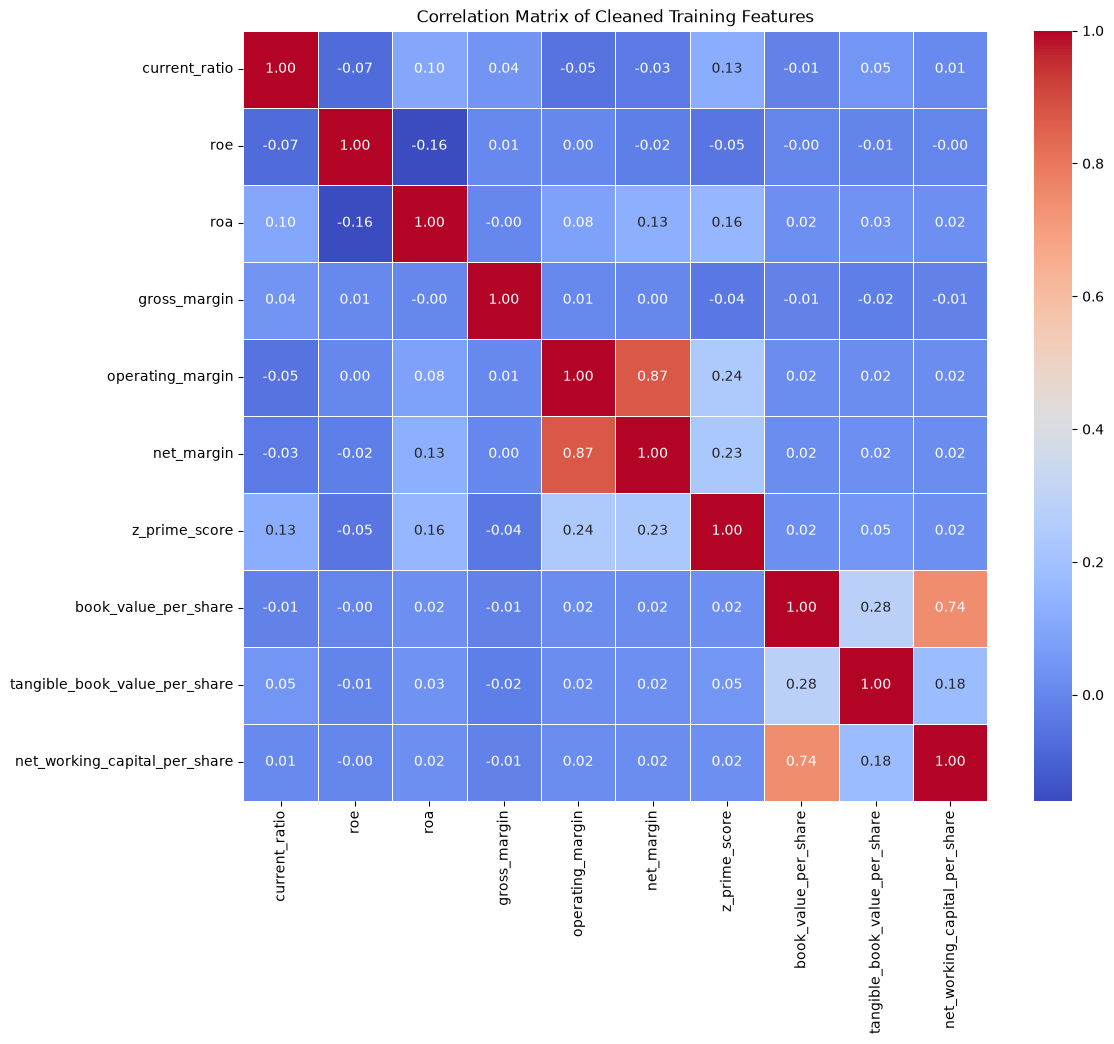

In [110]:
# --- 7. Exploratory Data Analysis (EDA) on Cleaned Training Data ---

print("\n--- EDA: Summary Statistics for Cleaned Training Data (X_train) ---")
display(X_train.describe())

print("\n--- EDA: Class Balance of target_bankrupt_1y in Training Set (y_train) ---")
class_balance = y_train.value_counts(normalize=True) * 100
print(class_balance)

# Generate a correlation matrix heatmap of the final cleaned training features
plt.figure(figsize=(12, 10))
sns.heatmap(X_train.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Cleaned Training Features')
plt.show()

In [111]:
# --- 8. Deliverables ---

print("\n--- Final DataFrames Shapes ---")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

print("\n--- Final Feature List ---")
print(final_features)

print("\n--- Top 3 Feature Correlations with Target Variable (y_train) ---")
# Combine X_train and y_train to calculate correlations
train_data_corr = X_train.copy()
train_data_corr[TARGET_VARIABLE] = y_train

correlations = train_data_corr.corr()[TARGET_VARIABLE].drop(TARGET_VARIABLE).abs().sort_values(ascending=False)
top_3_features = correlations.head(3)
print(top_3_features)


--- Final DataFrames Shapes ---
X_train shape: (162002, 10)
y_train shape: (162002,)
X_val shape: (32060, 10)
y_val shape: (32060,)
X_test shape: (33853, 10)
y_test shape: (33853,)

--- Final Feature List ---
['current_ratio', 'roe', 'roa', 'gross_margin', 'operating_margin', 'net_margin', 'z_prime_score', 'book_value_per_share', 'tangible_book_value_per_share', 'net_working_capital_per_share']

--- Top 3 Feature Correlations with Target Variable (y_train) ---
current_ratio    0.036617
z_prime_score    0.022138
gross_margin     0.021867
Name: target_bankrupt_1y, dtype: float64


In [112]:
# Ensure target variables are boolean and handle potential None values
y_train = y_train.astype(bool)
y_val = y_val.fillna(False).astype(bool) # Assume None means not bankrupt for target
y_test = y_test.fillna(False).astype(bool) # Assume None means not bankrupt for target

print("Target variables converted to boolean type.")
print(f"y_train type: {y_train.dtype}")
print(f"y_val type: {y_val.dtype}")
print(f"y_test type: {y_test.dtype}")

Target variables converted to boolean type.
y_train type: bool
y_val type: bool
y_test type: bool


In [113]:
# Install Julia dependencies for PySR
import pysr
pysr.install(confirm=True)

/Users/nakulbadwaik24/project/Research/SR_Bankruptcy/.venv/lib/python3.14/site-packages/pysr/deprecated.py:10: FutureWarning: The `install` function has been removed. PySR now uses the `juliacall` package to install its dependencies automatically at import time. 
  warnings.warn(


In [114]:
# Import necessary libraries for modeling and evaluation
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.calibration import CalibratedClassifierCV
from pysr import PySRRegressor # Removed best_programs import as it's not directly available
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Dictionary to store performance metrics for comparison
performance_metrics = {}

## 4. Compare interpretable baselines with symbolic regression

I first establish reference points with models that are familiar and relatively easy to inspect: Altman Z'-Score, logistic regression, and a shallow decision tree. These baselines show whether symbolic regression adds useful predictive structure beyond a known bankruptcy score, a linear classifier, and a simple rule-based model.

PySR then searches for compact nonlinear equations using the cleaned financial features. The search is configured with arithmetic and selected nonlinear operators, and it minimizes a logistic-loss expression. PySR returns a real-valued score, so the notebook applies the sigmoid function to convert that score into a bankruptcy probability before calculating classification metrics. The equations are useful because they can expose relationships that are more expressive than a linear model while remaining inspectable.

In [115]:
def evaluate_model(y_true, y_pred, y_proba=None, model_name="Model"):
    """Helper function to evaluate model performance and store metrics."""
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_true, y_proba) if y_proba is not None else np.nan

    global performance_metrics # Ensure performance_metrics is accessible globally
    performance_metrics[model_name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    }
    print(f"\n--- {model_name} Test Set Performance ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")

    return accuracy, precision, recall, f1, roc_auc

In [116]:
# --- 1. Baseline Models: Altman Z'-Score (z_prime_score) ---
print("\n--- Running Baseline 1: Altman Z'-Score ---")

# Optimize probability threshold on validation set
val_z_prime_score = X_val['z_prime_score'].values

# To optimize Youden's J, we need to try different thresholds
thresholds = np.unique(val_z_prime_score)
if len(thresholds) > 100:
    thresholds = np.linspace(val_z_prime_score.min(), val_z_prime_score.max(), 100)

best_j = -1
best_threshold_z = 0

for t in thresholds:
    # Assuming lower z_prime_score indicates higher bankruptcy risk (True class)
    # So, predict True (1) if z_prime_score <= t, else False (0)
    y_pred_val_z_score = (val_z_prime_score <= t).astype(int)

    tp = np.sum((y_pred_val_z_score == 1) & (y_val == True))
    fn = np.sum((y_pred_val_z_score == 0) & (y_val == True))
    fp = np.sum((y_pred_val_z_score == 1) & (y_val == False))
    tn = np.sum((y_pred_val_z_score == 0) & (y_val == False))

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    youden_j = sensitivity + specificity - 1

    if youden_j > best_j:
        best_j = youden_j
        best_threshold_z = t

print(f"Optimal Z'-Score threshold (Youden's J) on validation set: {best_threshold_z:.4f}")

# Apply optimized threshold to the test set
test_z_prime_score = X_test['z_prime_score'].values
y_pred_test_z_score = (test_z_prime_score <= best_threshold_z).astype(int)

# Altman Z'-Score probabilities (e.g., inverse of distance to threshold, or just use 1-normalized_score)
# A simple approach: use the score itself as a 'probability' for the ROC AUC,
# after appropriate scaling or inversion for direction.
# For ROC AUC, a higher value should indicate the positive class (bankrupt).
# So, a lower z_prime_score should map to a higher 'probability' of bankruptcy.
min_z = test_z_prime_score.min()
max_z = test_z_prime_score.max()
if (max_z - min_z) != 0:
    y_proba_test_z_score = 1 - (test_z_prime_score - min_z) / (max_z - min_z)
else:
    y_proba_test_z_score = np.zeros_like(test_z_prime_score)

# Evaluate Altman Z'-Score
evaluate_model(y_test, y_pred_test_z_score, y_proba_test_z_score, "Altman Z'-Score")


--- Running Baseline 1: Altman Z'-Score ---
Optimal Z'-Score threshold (Youden's J) on validation set: 0.4139

--- Altman Z'-Score Test Set Performance ---
Accuracy: 0.7322
Precision: 0.0303
Recall: 0.7143
F1-Score: 0.0582
ROC-AUC: 0.7602


(0.7321950787227129,
 0.030322720381199913,
 0.7142857142857143,
 0.0581757739455641,
 0.7602123916420518)

In [117]:
# --- 2. Baseline Models: Logistic Regression ---
print("\n--- Running Baseline 2: Logistic Regression ---")

# Initialize and train Logistic Regression model with balanced class weights
log_reg = LogisticRegression(solver='liblinear', class_weight='balanced', random_state=42, max_iter=1000)
log_reg.fit(X_train, y_train)

# Predict on test set
y_pred_test_log_reg = log_reg.predict(X_test)
y_proba_test_log_reg = log_reg.predict_proba(X_test)[:, 1]

# Evaluate Logistic Regression
evaluate_model(y_test, y_pred_test_log_reg, y_proba_test_log_reg, "Logistic Regression")


--- Running Baseline 2: Logistic Regression ---

--- Logistic Regression Test Set Performance ---
Accuracy: 0.6155
Precision: 0.0215
Recall: 0.7245
F1-Score: 0.0418
ROC-AUC: 0.7216


(0.6155141346409476,
 0.02152819890842935,
 0.7244897959183674,
 0.04181389870435807,
 0.7216249773571304)

In [118]:
# --- 3. Baseline Models: Decision Tree ---
print("\n--- Running Baseline 3: Decision Tree ---")

# Initialize and train Decision Tree Classifier
dec_tree = DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=42)
dec_tree.fit(X_train, y_train)

# Print text representation of the tree
print("\nDecision Tree Rules (max_depth=3):")
print(export_text(dec_tree, feature_names=list(X_train.columns)))

# Predict on test set
y_pred_test_dec_tree = dec_tree.predict(X_test)
y_proba_test_dec_tree = dec_tree.predict_proba(X_test)[:, 1]

# Evaluate Decision Tree
evaluate_model(y_test, y_pred_test_dec_tree, y_proba_test_dec_tree, "Decision Tree")


--- Running Baseline 3: Decision Tree ---

Decision Tree Rules (max_depth=3):
|--- roa <= -0.00
|   |--- current_ratio <= 4.48
|   |   |--- net_working_capital_per_share <= -0.12
|   |   |   |--- class: True
|   |   |--- net_working_capital_per_share >  -0.12
|   |   |   |--- class: True
|   |--- current_ratio >  4.48
|   |   |--- roe <= 0.02
|   |   |   |--- class: False
|   |   |--- roe >  0.02
|   |   |   |--- class: False
|--- roa >  -0.00
|   |--- current_ratio <= 0.87
|   |   |--- book_value_per_share <= -0.19
|   |   |   |--- class: True
|   |   |--- book_value_per_share >  -0.19
|   |   |   |--- class: False
|   |--- current_ratio >  0.87
|   |   |--- roa <= 0.00
|   |   |   |--- class: False
|   |   |--- roa >  0.00
|   |   |   |--- class: False


--- Decision Tree Test Set Performance ---
Accuracy: 0.6288
Precision: 0.0262
Recall: 0.8571
F1-Score: 0.0508
ROC-AUC: 0.7877


(0.6288069004224146,
 0.026156001868285848,
 0.8571428571428571,
 0.050762955129173594,
 0.7877310640044547)

In [119]:
# --- 4. Symbolic Regression Experiment (PySR) - Run 1 (random_state=0) ---
print("\n--- Running Symbolic Regression (PySR) - Run 1 (random_state=0) ---")

import re
import sympy as sp
from scipy.special import expit

model_sro_rs0 = PySRRegressor(
    model_selection='best',
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["square", "sqrt", "exp", "log"],
    niterations=500,
    populations=5,
    population_size=100,
    parsimony=0.01,
    complexity_of_constants=5,
    batching=True,
    cluster_manager=None,
    extra_sympy_mappings={'square': lambda x: x**2, 'sqrt': sp.sqrt, 'exp': sp.exp, 'log': sp.log},
    elementwise_loss='(x, y) -> (z = 1 / (1 + exp(-x)); -y * log(max(1e-10, z)) - (1 - y) * log(max(1e-10, 1 - z)))',
    random_state=0,
    deterministic=True,
    parallelism='serial',
)

X_train_np = X_train.values
y_train_np = y_train.values.astype(int)
X_val_np = X_val.values
y_val_np = y_val.values.astype(int)

model_sro_rs0.fit(X_train_np, y_train_np, variable_names=list(final_features))

feature_pattern_rs0 = re.compile('|'.join(re.escape(feature) for feature in final_features))
variable_equations_rs0 = model_sro_rs0.equations_[
    model_sro_rs0.equations_['equation'].astype(str).map(feature_pattern_rs0.search).notna()
]
if variable_equations_rs0.empty:
    raise RuntimeError("PySR Run 1 found no equation containing a feature. Increase the search budget.")
selected_index_rs0 = variable_equations_rs0['loss'].idxmin()
best_equation_rs0 = model_sro_rs0.equations_.loc[selected_index_rs0]
print("\nBest variable-containing equation from PySR Run 1:")
print(best_equation_rs0)

# PySR returns the raw equation output; convert logits to probabilities for classification metrics.
y_score_test_sro_rs0 = model_sro_rs0.predict(X_test.values, index=selected_index_rs0)
y_proba_test_sro_rs0 = expit(y_score_test_sro_rs0)
y_pred_test_sro_rs0 = (y_proba_test_sro_rs0 > 0.5).astype(int)

evaluate_model(y_test, y_pred_test_sro_rs0, y_proba_test_sro_rs0, "PySR (random_state=0)")


--- Running Symbolic Regression (PySR) - Run 1 (random_state=0) ---


/Users/nakulbadwaik24/project/Research/SR_Bankruptcy/.venv/lib/python3.14/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 6.440e+02
Progress: 26 / 2500 total iterations (1.040%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
2           7.773e-01  0.000e+00  y = square(gross_margin)
3           2.125e-01  1.297e+00  y = net_margin - current_ratio
4           9.581e-02  7.966e-01  y = net_margin - exp(current_ratio)
5           4.604e-02  7.328e-01  y = -4.7306
20          4.601e-02  4.624e-05  y = (log(0.71058) + -2.3995) * square(log(0.26284))
───────────────────────────────────────────────────────────────────────────────────────────────────
════════════════════════════════════════════════════════════════════════════════════════════════════
Press 'q' and then <enter> to stop execution early.

Expressions evaluated per second: 6.190e+02
Progress: 52 / 2500 total iterations (2.0

[ Info: Final population:
[ Info: Results saved to:


(0.9884205240303666, 0.0, 0.0, 0.0, 0.8000268664891019)

  - outputs/20260820_173141_U46oY3/hall_of_fame.csv


In [120]:
# --- 5. Symbolic Regression Experiment (PySR) - Run 2 (random_state=42) ---
print("\n--- Running Symbolic Regression (PySR) - Run 2 (random_state=42) ---")

model_sro_rs42 = PySRRegressor(
    model_selection='best',
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["square", "sqrt", "exp", "log"],
    niterations=500,
    populations=5,
    population_size=100,
    parsimony=0.01,
    complexity_of_constants=5,
    batching=True,
    cluster_manager=None,
    extra_sympy_mappings={'square': lambda x: x**2, 'sqrt': sp.sqrt, 'exp': sp.exp, 'log': sp.log},
    elementwise_loss='(x, y) -> (z = 1 / (1 + exp(-x)); -y * log(max(1e-10, z)) - (1 - y) * log(max(1e-10, 1 - z)))',
    random_state=42,
    deterministic=True,
    parallelism='serial',
)

model_sro_rs42.fit(X_train_np, y_train_np, variable_names=list(final_features))

feature_pattern_rs42 = re.compile('|'.join(re.escape(feature) for feature in final_features))
variable_equations_rs42 = model_sro_rs42.equations_[
    model_sro_rs42.equations_['equation'].astype(str).map(feature_pattern_rs42.search).notna()
]
if variable_equations_rs42.empty:
    raise RuntimeError("PySR Run 2 found no equation containing a feature. Increase the search budget.")
selected_index_rs42 = variable_equations_rs42['loss'].idxmin()
best_equation_rs42 = model_sro_rs42.equations_.loc[selected_index_rs42]
print("\nBest variable-containing equation from PySR Run 2:")
print(best_equation_rs42)

y_score_test_sro_rs42 = model_sro_rs42.predict(X_test.values, index=selected_index_rs42)
y_proba_test_sro_rs42 = expit(y_score_test_sro_rs42)
y_pred_test_sro_rs42 = (y_proba_test_sro_rs42 > 0.5).astype(int)

evaluate_model(y_test, y_pred_test_sro_rs42, y_proba_test_sro_rs42, "PySR (random_state=42)")

/Users/nakulbadwaik24/project/Research/SR_Bankruptcy/.venv/lib/python3.14/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(



--- Running Symbolic Regression (PySR) - Run 2 (random_state=42) ---


[ Info: Started!



Expressions evaluated per second: 5.810e+02
Progress: 24 / 2500 total iterations (0.960%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           6.269e-01  0.000e+00  y = roa
3           1.860e-01  6.076e-01  y = roa - current_ratio
4           7.922e-02  8.534e-01  y = roa - exp(current_ratio)
5           4.602e-02  5.432e-01  y = -4.9064
13          4.504e-02  2.669e-03  y = (-1.812 - current_ratio) + -1.812
14          4.421e-02  1.868e-02  y = (-1.812 - sqrt(current_ratio)) + -1.812
───────────────────────────────────────────────────────────────────────────────────────────────────
════════════════════════════════════════════════════════════════════════════════════════════════════
Press 'q' and then <enter> to stop execution early.

Expressions evaluated per second: 6.250e+02
Progress

[ Info: Final population:
[ Info: Results saved to:


(0.9884205240303666, 0.0, 0.0, 0.0, 0.7697209483596196)

  - outputs/20260820_173946_22kt4o/hall_of_fame.csv


In [121]:
# --- 6. Extract equations and compute compactness metrics ---

from collections import Counter
from numbers import Number


def equation_details(equation_row, run_name):
    equation_text = str(equation_row['equation'])
    sympy_text = str(equation_row.get('sympy_format', equation_text))
    expression = sp.sympify(sympy_text)
    used_features = sorted(
        symbol.name for symbol in expression.free_symbols
        if symbol.name in final_features
    )

    def tree_depth(node):
        children = list(node.args)
        return 1 if not children else 1 + max(tree_depth(child) for child in children)

    operator_count = sum(
        1 for node in sp.preorder_traversal(expression)
        if node.args and not isinstance(node, (sp.Symbol, sp.Number))
    )
    total_nodes = sum(1 for _ in sp.preorder_traversal(expression))
    variable_and_constant_nodes = sum(
        1 for node in sp.preorder_traversal(expression)
        if isinstance(node, (sp.Symbol, sp.Number))
    )

    return {
        'Run': run_name,
        'Equation': equation_text,
        'SymPy': sympy_text,
        'LaTeX': sp.latex(expression),
        'Number of variables': len(used_features),
        'Variables used': used_features,
        'Number of operators': operator_count,
        'Total expression nodes': total_nodes,
        'Equation depth': tree_depth(expression),
        'Character length': len(equation_text),
        'Complexity': int(equation_row['complexity']),
        'Loss': float(equation_row['loss'])
    }


def print_equation_table(equations, run_name):
    print(f"\n--- {run_name}: Top 2 Variable-Containing Equations ---")
    details = []
    for rank, (_, row) in enumerate(equations.nsmallest(2, 'loss').iterrows(), start=1):
        item = equation_details(row, run_name)
        details.append(item)
        print(f"\nRank {rank}")
        print(f"Plain text: {item['Equation']}")
        print(f"LaTeX: ${item['LaTeX']}$")
        print(f"Variables: {item['Variables used']}")
        print(f"Operators: {item['Number of operators']}")
        print(f"Total nodes: {item['Total expression nodes']}")
        print(f"Depth: {item['Equation depth']}")
        print(f"Character length: {item['Character length']}")
        print(f"Complexity: {item['Complexity']}; loss: {item['Loss']:.6f}")
    return details

variable_equations_rs0 = model_sro_rs0.equations_[
    model_sro_rs0.equations_['equation'].astype(str).map(feature_pattern_rs0.search).notna()
]
variable_equations_rs42 = model_sro_rs42.equations_[
    model_sro_rs42.equations_['equation'].astype(str).map(feature_pattern_rs42.search).notna()
]
if variable_equations_rs0.empty or variable_equations_rs42.empty:
    raise RuntimeError("At least one PySR hall of fame contains no variable-containing equation.")

equation_details_rs0 = print_equation_table(variable_equations_rs0, "PySR random_state=0")
equation_details_rs42 = print_equation_table(variable_equations_rs42, "PySR random_state=42")

best_equation_rs0 = variable_equations_rs0.nsmallest(1, 'loss').iloc[0]
best_equation_rs42 = variable_equations_rs42.nsmallest(1, 'loss').iloc[0]



--- PySR random_state=0: Top 2 Variable-Containing Equations ---

Rank 1
Plain text: (-3.2710512 - sqrt(current_ratio)) - (exp(net_margin + 1.1332897) * (net_margin + gross_margin))
LaTeX: $- \sqrt{current_{ratio}} - 3.10585705048914 \left(gross_{margin} + net_{margin}\right) e^{net_{margin}} - 3.2710512$
Variables: ['current_ratio', 'gross_margin', 'net_margin']
Operators: 6
Total nodes: 14
Depth: 4
Character length: 96
Complexity: 21; loss: 0.042786

Rank 2
Plain text: (-3.2710512 - sqrt(current_ratio)) - (exp(net_margin) * (net_margin + gross_margin))
LaTeX: $- \sqrt{current_{ratio}} - \left(gross_{margin} + net_{margin}\right) e^{net_{margin}} - 3.2710512$
Variables: ['current_ratio', 'gross_margin', 'net_margin']
Operators: 6
Total nodes: 14
Depth: 4
Character length: 84
Complexity: 15; loss: 0.043053

--- PySR random_state=42: Top 2 Variable-Containing Equations ---

Rank 1
Plain text: (-3.6363935 - sqrt(current_ratio)) - (-1.4363189 + (0.9287361 + exp(net_margin)))
LaTeX: $- \s

In [122]:
# --- 7. Re-evaluate probabilistic models with validation-optimized thresholds ---

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


def optimize_f1_threshold(y_true, probabilities):
    threshold_grid = np.arange(0.01, 1.00, 0.01)
    scores = []
    for threshold in threshold_grid:
        predictions = (probabilities >= threshold).astype(int)
        scores.append(f1_score(y_true, predictions, zero_division=0))
    best_position = int(np.argmax(scores))
    return float(threshold_grid[best_position]), float(scores[best_position])


# Use validation-derived scaling for Altman scores, avoiding test-set information leakage.
val_z_min = X_val['z_prime_score'].min()
val_z_max = X_val['z_prime_score'].max()
val_z_range = val_z_max - val_z_min
altman_val_proba = 1 - (X_val['z_prime_score'].values - val_z_min) / val_z_range
altman_test_proba = 1 - (X_test['z_prime_score'].values - val_z_min) / val_z_range
altman_val_proba = np.clip(altman_val_proba, 0, 1)
altman_test_proba = np.clip(altman_test_proba, 0, 1)

probability_models = {
    "Altman Z'-Score": (
        altman_val_proba,
        altman_test_proba
    ),
    "Logistic Regression": (
        log_reg.predict_proba(X_val)[:, 1],
        log_reg.predict_proba(X_test)[:, 1]
    ),
    "PySR (random_state=0)": (
        expit(model_sro_rs0.predict(X_val.values, index=best_equation_rs0.name)),
        expit(model_sro_rs0.predict(X_test.values, index=best_equation_rs0.name))
    ),
    "PySR (random_state=42)": (
        expit(model_sro_rs42.predict(X_val.values, index=best_equation_rs42.name)),
        expit(model_sro_rs42.predict(X_test.values, index=best_equation_rs42.name))
    )
}

optimized_results = {}
for model_name, (val_probabilities, test_probabilities) in probability_models.items():
    optimal_threshold, validation_f1 = optimize_f1_threshold(y_val, val_probabilities)
    test_predictions = (test_probabilities >= optimal_threshold).astype(int)
    optimized_results[model_name] = {
        'Optimal Threshold': optimal_threshold,
        'Validation F1': validation_f1,
        'Accuracy': accuracy_score(y_test, test_predictions),
        'Precision': precision_score(y_test, test_predictions, zero_division=0),
        'Recall': recall_score(y_test, test_predictions, zero_division=0),
        'F1-Score': f1_score(y_test, test_predictions, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, test_probabilities)
    }

# Decision Tree emits discrete classes, so retain its original test-set evaluation.
decision_tree_metrics = performance_metrics.get('Decision Tree', {})
optimized_results['Decision Tree'] = {
    'Optimal Threshold': 'N/A',
    'Validation F1': np.nan,
    'Accuracy': decision_tree_metrics.get('Accuracy', np.nan),
    'Precision': decision_tree_metrics.get('Precision', np.nan),
    'Recall': decision_tree_metrics.get('Recall', np.nan),
    'F1-Score': decision_tree_metrics.get('F1-Score', np.nan),
    'ROC-AUC': decision_tree_metrics.get('ROC-AUC', np.nan)
}

model_order = [
    "Altman Z'-Score",
    "Logistic Regression",
    "Decision Tree",
    "PySR (random_state=0)",
    "PySR (random_state=42)"
]
optimized_performance_df = pd.DataFrame.from_dict(optimized_results, orient='index').loc[model_order]
print("\n--- Test Performance with Validation-Optimized F1 Thresholds ---")
display(optimized_performance_df.round(4))
print("\n" + optimized_performance_df.round(4).to_markdown())



--- Test Performance with Validation-Optimized F1 Thresholds ---


,Optimal Threshold,Validation F1,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Altman Z'-Score,0.07,0.0167,0.8069,0.0354,0.5969,0.0668,0.7602
Logistic Regression,0.68,0.0346,0.9439,0.0408,0.1709,0.0659,0.7216
Decision Tree,N/A,NaN,0.6288,0.0262,0.8571,0.0508,0.7877
PySR (random_state=0),0.04,0.0554,0.9768,0.0583,0.0663,0.0621,0.8000
PySR (random_state=42),0.01,0.0309,0.8697,0.0345,0.3801,0.0633,0.7697



|                        | Optimal Threshold   |   Validation F1 |   Accuracy |   Precision |   Recall |   F1-Score |   ROC-AUC |
|:-----------------------|:--------------------|----------------:|-----------:|------------:|---------:|-----------:|----------:|
| Altman Z'-Score        | 0.07                |          0.0167 |     0.8069 |      0.0354 |   0.5969 |     0.0668 |    0.7602 |
| Logistic Regression    | 0.68                |          0.0346 |     0.9439 |      0.0408 |   0.1709 |     0.0659 |    0.7216 |
| Decision Tree          | N/A                 |        nan      |     0.6288 |      0.0262 |   0.8571 |     0.0508 |    0.7877 |
| PySR (random_state=0)  | 0.04                |          0.0554 |     0.9768 |      0.0583 |   0.0663 |     0.0621 |    0.8    |
| PySR (random_state=42) | 0.01                |          0.0309 |     0.8697 |      0.0345 |   0.3801 |     0.0633 |    0.7697 |


## 5. Select thresholds on validation data

Bankruptcy is an imbalanced classification problem, so the default probability threshold of 0.50 may not be the most useful operating point. I search for the threshold that gives the highest validation-set F1-score for each probabilistic model. F1 balances precision and recall, which is useful when both missed bankruptcies and unnecessary warnings matter.

The chosen threshold is then frozen and applied to the test probabilities. The test set therefore measures how well the complete decision rule generalizes; it is not used to tune the cutoff. ROC-AUC is also reported because it evaluates ranking quality across thresholds rather than at only one operating point.

In [123]:
# --- 8. Stability analysis and final interpretation ---

variables_rs0 = set(equation_details_rs0[0]['Variables used'])
variables_rs42 = set(equation_details_rs42[0]['Variables used'])
union_variables = variables_rs0 | variables_rs42
intersection_variables = variables_rs0 & variables_rs42
jaccard_overlap = (
    len(intersection_variables) / len(union_variables)
    if union_variables else 1.0
)

operators_rs0 = set(re.findall(r'\b(?:square|sqrt|exp|log)\b|[+*/-]', equation_details_rs0[0]['Equation']))
operators_rs42 = set(re.findall(r'\b(?:square|sqrt|exp|log)\b|[+*/-]', equation_details_rs42[0]['Equation']))
shared_operators = operators_rs0 & operators_rs42

print("\n--- Preliminary SR Stability Analysis ---")
print(f"Run 1 variables: {sorted(variables_rs0)}")
print(f"Run 2 variables: {sorted(variables_rs42)}")
print(f"Shared variables: {sorted(intersection_variables)}")
print(f"Variable-selection Jaccard similarity: {jaccard_overlap:.4f}")
print(f"Run 1 operators: {sorted(operators_rs0)}")
print(f"Run 2 operators: {sorted(operators_rs42)}")
print(f"Shared operator types: {sorted(shared_operators)}")

best_sr_name = max(
    (name for name in optimized_results if name.startswith('PySR')),
    key=lambda name: optimized_results[name]['F1-Score']
)
best_sr_f1 = optimized_results[best_sr_name]['F1-Score']
logistic_f1 = optimized_results['Logistic Regression']['F1-Score']

if jaccard_overlap >= 0.75:
    stability_comment = "The two runs show strong variable-selection stability."
elif jaccard_overlap > 0:
    stability_comment = "The two runs share some variables, but the discovered relationship is only partially stable."
else:
    stability_comment = "The two runs select disjoint variables, indicating substantial instability across seeds."

interpretation_statement = (
    f"After validation-based threshold optimization, the best SR model ({best_sr_name}) "
    f"achieved test F1-score {best_sr_f1:.4f}, compared with Logistic Regression "
    f"at {logistic_f1:.4f}. The SR equations are economically interpretable only as "
    f"candidate nonlinear score functions: Run 1 uses {sorted(variables_rs0)}, while "
    f"Run 2 uses {sorted(variables_rs42)}. Their variable-selection Jaccard similarity "
    f"is {jaccard_overlap:.4f}; {stability_comment} Equation complexity and the use of "
    f"nonlinear operators also require out-of-sample and economic validation before "
    f"the equations should be treated as reliable bankruptcy mechanisms."
)
print("\n--- Interpretation ---")
print(interpretation_statement)



--- Preliminary SR Stability Analysis ---
Run 1 variables: ['current_ratio', 'gross_margin', 'net_margin']
Run 2 variables: ['current_ratio', 'net_margin']
Shared variables: ['current_ratio', 'net_margin']
Variable-selection Jaccard similarity: 0.6667
Run 1 operators: ['*', '+', '-', 'exp', 'sqrt']
Run 2 operators: ['+', '-', 'exp', 'sqrt']
Shared operator types: ['+', '-', 'exp', 'sqrt']

--- Interpretation ---
After validation-based threshold optimization, the best SR model (PySR (random_state=42)) achieved test F1-score 0.0633, compared with Logistic Regression at 0.0659. The SR equations are economically interpretable only as candidate nonlinear score functions: Run 1 uses ['current_ratio', 'gross_margin', 'net_margin'], while Run 2 uses ['current_ratio', 'net_margin']. Their variable-selection Jaccard similarity is 0.6667; The two runs share some variables, but the discovered relationship is only partially stable. Equation complexity and the use of nonlinear operators also requir

In [124]:
# --- 9. Step 7: Temporal Validation Across Economic Eras ---

from sklearn.metrics import f1_score, roc_auc_score

# Use the original filtered training DataFrame for fiscal-year subdivision.
# Rows without a fiscal year cannot be assigned to a chronological bucket.
train_years = pd.to_numeric(df.loc[X_train.index, 'fiscal_year'], errors='coerce')
valid_years = train_years.notna()

period_masks = {
    'Train (Early) 2008-2015': valid_years & train_years.between(2008, 2015),
    'Validate (Mid) 2016-2017': valid_years & train_years.between(2016, 2017),
    'Test (Late) 2018-2019': valid_years & train_years.between(2018, 2019)
}

X_train_early = X_train.loc[period_masks['Train (Early) 2008-2015']].copy()
y_train_early = y_train.loc[X_train_early.index].astype(int)
X_validate_mid = X_train.loc[period_masks['Validate (Mid) 2016-2017']].copy()
y_validate_mid = y_train.loc[X_validate_mid.index].astype(int)
X_test_late = X_train.loc[period_masks['Test (Late) 2018-2019']].copy()
y_test_late = y_train.loc[X_test_late.index].astype(int)

period_data = {
    'Train (Early) 2008-2015': (X_train_early, y_train_early),
    'Validate (Mid) 2016-2017': (X_validate_mid, y_validate_mid),
    'Test (Late) 2018-2019': (X_test_late, y_test_late),
    'COVID 2020-2021': (X_val.copy(), y_val.astype(int)),
    'Post-COVID 2022-2023': (X_test.copy(), y_test.astype(int))
}

period_summary = pd.DataFrame([
    {
        'Time Period': period_name,
        'Rows': len(period_target),
        'Bankruptcies': int(period_target.sum()),
        'Bankruptcy Rate': float(period_target.mean())
    }
    for period_name, (_, period_target) in period_data.items()
]).set_index('Time Period')

print("\n--- Chronological Sub-Period Class Distribution ---")
display(period_summary.round({'Bankruptcy Rate': 4}))
print(period_summary.round({'Bankruptcy Rate': 4}).to_markdown())

if (period_summary['Bankruptcies'] == 0).any():
    raise ValueError("At least one temporal period contains no bankruptcies; ROC-AUC/F1 would be unreliable.")

# Train a separate PySR model only on the early period.
temporal_model = PySRRegressor(
    model_selection='best',
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["square", "sqrt", "exp", "log"],
    niterations=150,
    populations=5,
    population_size=100,
    parsimony=0.01,
    complexity_of_constants=5,
    batching=True,
    cluster_manager=None,
    extra_sympy_mappings={'square': lambda x: x**2, 'sqrt': sp.sqrt, 'exp': sp.exp, 'log': sp.log},
    elementwise_loss='(x, y) -> (z = 1 / (1 + exp(-x)); -y * log(max(1e-10, z)) - (1 - y) * log(max(1e-10, 1 - z)))',
    random_state=0,
    deterministic=True,
    parallelism='serial'
)

temporal_model.fit(
    X_train_early.values,
    y_train_early.values,
    variable_names=list(final_features)
)

temporal_feature_pattern = re.compile('|'.join(re.escape(feature) for feature in final_features))
temporal_variable_equations = temporal_model.equations_[
    temporal_model.equations_['equation'].astype(str).map(temporal_feature_pattern.search).notna()
]
if temporal_variable_equations.empty:
    raise RuntimeError("The early-period PySR run found no variable-containing equation.")

temporal_equation_row = temporal_variable_equations.nsmallest(1, 'loss').iloc[0]
temporal_equation = equation_details(temporal_equation_row, 'Early temporal PySR')
temporal_equation_index = temporal_equation_row.name

print("\n--- Early-Period PySR Equation ---")
print(f"Plain text: {temporal_equation['Equation']}")
print(f"LaTeX: ${temporal_equation['LaTeX']}$")
print(f"Variables: {temporal_equation['Variables used']}")
print(f"Number of operators: {temporal_equation['Number of operators']}")
print(f"Equation depth: {temporal_equation['Equation depth']}")
print(f"Character length: {temporal_equation['Character length']}")
print(f"Complexity: {temporal_equation['Complexity']}; loss: {temporal_equation['Loss']:.6f}")

# Evaluate the fixed early-period equation as a score function across all eras.
def temporal_probabilities(features):
    raw_scores = temporal_model.predict(features.values, index=temporal_equation_index)
    return expit(raw_scores)

period_probabilities = {
    period_name: temporal_probabilities(period_features)
    for period_name, (period_features, _) in period_data.items()
}

threshold_grid = np.arange(0.01, 1.00, 0.01)
mid_probabilities = period_probabilities['Validate (Mid) 2016-2017']
mid_threshold_scores = [
    f1_score(y_validate_mid, mid_probabilities >= threshold, zero_division=0)
    for threshold in threshold_grid
]
temporal_threshold = float(threshold_grid[int(np.argmax(mid_threshold_scores))])

print(f"\nThreshold selected on Validate (Mid) 2016-2017: {temporal_threshold:.2f}")

temporal_results = []
for period_name, (_, period_target) in period_data.items():
    period_probabilities_current = period_probabilities[period_name]
    period_predictions = period_probabilities_current >= temporal_threshold
    temporal_results.append({
        'Time Period': period_name,
        'ROC-AUC': roc_auc_score(period_target, period_probabilities_current),
        'F1-Score (shared mid threshold)': f1_score(period_target, period_predictions, zero_division=0),
        'Positive Predictions': int(period_predictions.sum())
    })

temporal_performance_df = pd.DataFrame(temporal_results).set_index('Time Period')
print("\n--- Temporal Performance of Fixed Early-Period Equation ---")
display(temporal_performance_df.round(4))
print(temporal_performance_df.round(4).to_markdown())

# Compare variables in the early equation with the existing full-period Run 1 equation.
full_period_variables = set(equation_details_rs0[0]['Variables used'])
early_period_variables = set(temporal_equation['Variables used'])
variable_union = early_period_variables | full_period_variables
variable_intersection = early_period_variables & full_period_variables
temporal_jaccard = len(variable_intersection) / len(variable_union) if variable_union else 1.0

print("\n--- Temporal Equation Structure Comparison ---")
print(f"Variables used in 2008-2015 equation: {sorted(early_period_variables)}")
print(f"Variables used in 2008-2019 equation: {sorted(full_period_variables)}")
print(f"Shared variables: {sorted(variable_intersection)}")
print(f"Jaccard similarity: {temporal_jaccard:.4f}")

if temporal_performance_df.loc['COVID 2020-2021', 'ROC-AUC'] < temporal_performance_df.loc['Test (Late) 2018-2019', 'ROC-AUC']:
    temporal_comment = "Ranking performance declines during the COVID era."
elif temporal_performance_df.loc['Post-COVID 2022-2023', 'ROC-AUC'] < temporal_performance_df.loc['Test (Late) 2018-2019', 'ROC-AUC']:
    temporal_comment = "Ranking performance declines in the post-COVID period."
else:
    temporal_comment = "Ranking performance does not show a simple decline across the later eras."

print(
    f"Economic interpretation: The early-period equation uses {sorted(early_period_variables)}, "
    f"which is directionally plausible because liquidity and profitability measures can be related "
    f"to default risk. The early-to-full-period variable overlap is {temporal_jaccard:.4f}; "
    f"{temporal_comment} These results provide preliminary evidence about temporal stability, "
    f"but the small bankruptcy counts and threshold tuning on one mid-period require cautious interpretation."
)



--- Chronological Sub-Period Class Distribution ---


,Rows,Bankruptcies,Bankruptcy Rate
Time Period,,,
Train (Early) 2008-2015,95413,641,0.0067
Validate (Mid) 2016-2017,33798,294,0.0087
Test (Late) 2018-2019,31107,325,0.0104
COVID 2020-2021,32060,136,0.0042
Post-COVID 2022-2023,33853,392,0.0116


| Time Period              |   Rows |   Bankruptcies |   Bankruptcy Rate |
|:-------------------------|-------:|---------------:|------------------:|
| Train (Early) 2008-2015  |  95413 |            641 |            0.0067 |
| Validate (Mid) 2016-2017 |  33798 |            294 |            0.0087 |
| Test (Late) 2018-2019    |  31107 |            325 |            0.0104 |
| COVID 2020-2021          |  32060 |            136 |            0.0042 |
| Post-COVID 2022-2023     |  33853 |            392 |            0.0116 |


/Users/nakulbadwaik24/project/Research/SR_Bankruptcy/.venv/lib/python3.14/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 1.170e+03
Progress: 49 / 750 total iterations (6.533%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           8.933e-01  0.000e+00  y = gross_margin
2           7.763e-01  1.403e-01  y = square(gross_margin)
3           1.819e-01  1.451e+00  y = roa - current_ratio
4           7.236e-02  9.217e-01  y = roa - exp(current_ratio)
5           4.031e-02  5.851e-01  y = -4.9741
26          4.010e-02  2.471e-04  y = (((-1.4594 * log(0.73208)) / -0.087026) - gross_margin...
                                      ) + 0.65852
───────────────────────────────────────────────────────────────────────────────────────────────────
════════════════════════════════════════════════════════════════════════════════════════════════════
Press 'q' and then <enter> to stop executi

[ Info: Final population:
[ Info: Results saved to:



--- Temporal Performance of Fixed Early-Period Equation ---


,ROC-AUC,F1-Score (shared mid threshold),Positive Predictions
Time Period,,,
Train (Early) 2008-2015,0.7009,0.0294,22237
Validate (Mid) 2016-2017,0.7038,0.0377,8308
Test (Late) 2018-2019,0.7193,0.0476,7666
COVID 2020-2021,0.7626,0.0239,6317
Post-COVID 2022-2023,0.6734,0.0451,7064


| Time Period              |   ROC-AUC |   F1-Score (shared mid threshold) |   Positive Predictions |
|:-------------------------|----------:|----------------------------------:|-----------------------:|
| Train (Early) 2008-2015  |    0.7009 |                            0.0294 |                  22237 |
| Validate (Mid) 2016-2017 |    0.7038 |                            0.0377 |                   8308 |
| Test (Late) 2018-2019    |    0.7193 |                            0.0476 |                   7666 |
| COVID 2020-2021          |    0.7626 |                            0.0239 |                   6317 |
| Post-COVID 2022-2023     |    0.6734 |                            0.0451 |                   7064 |

--- Temporal Equation Structure Comparison ---
Variables used in 2008-2015 equation: ['current_ratio', 'gross_margin']
Variables used in 2008-2019 equation: ['current_ratio', 'gross_margin', 'net_margin']
Shared variables: ['current_ratio', 'gross_margin']
Jaccard similarity: 0.6667
E

## 6. Check stability across economic eras

A strong score should not only fit one random split; it should remain informative when economic conditions change. I therefore train a separate symbolic equation on the early period, select its threshold using the middle period, and evaluate the unchanged equation and threshold across later periods, including the COVID and post-COVID eras.

The temporal table reports ROC-AUC, F1 at the shared threshold, positive predictions, and bankruptcy counts. These results show whether the equation continues to rank risk consistently over time. The variable-overlap comparison also indicates whether the economic signals selected in the early period resemble those found in the broader experiment. Because some periods may contain relatively few bankruptcies, the temporal findings should be interpreted as preliminary evidence rather than definitive proof of stability.